# EXERCISE 3: Advanced Feature Extraction and Image Processing

## Harris Corner Detection

In [ ]:
from google.colab import files
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

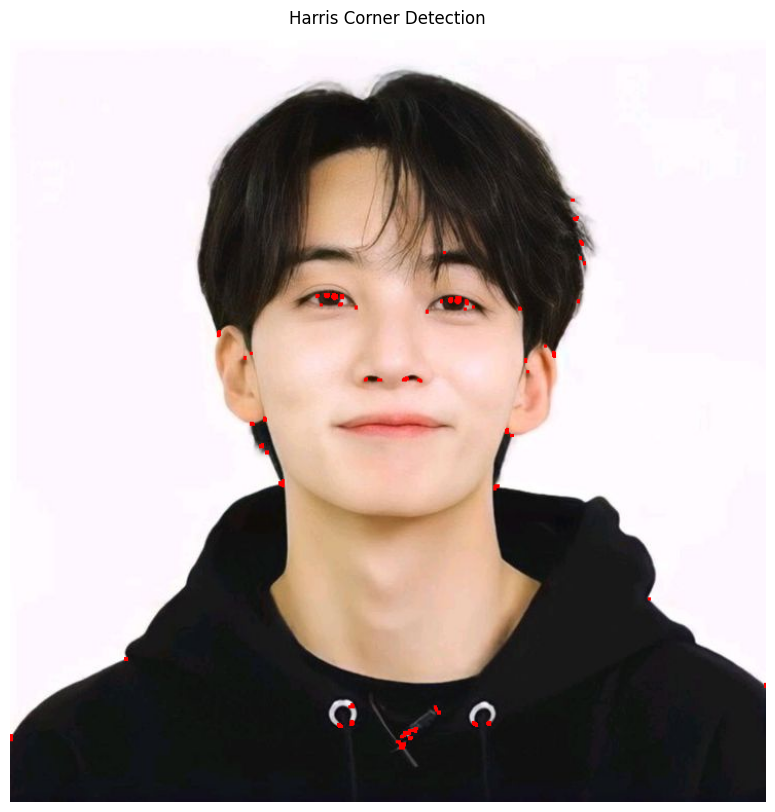

In [ ]:
# Define the path to the input image
image_path = "image.jpg"

# Read the image from the specified path
image = cv2.imread(image_path)

# Convert the image from BGR color space to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Convert the grayscale image to a float32 format for processing
gray = np.float32(gray)

# Apply the Harris corner detection algorithm
dst = cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04)

# Dilate the corner points to enhance them for visualization
dst = cv2.dilate(dst, None)

# Mark the corners in the original image with red color
image[dst > 0.02 * dst.max()] = [0, 0, 255]

# Set up the figure for displaying the image
plt.figure(figsize=(10, 10))

# Convert the image from BGR to RGB color space for correct display
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

# Set the title of the plot
plt.title('Harris Corner Detection')

# Turn off the axis for a cleaner presentation
plt.axis('off')

# Show the final result
plt.show()

## HOG (Histogram of Oriented Gradients) Feature Extraction

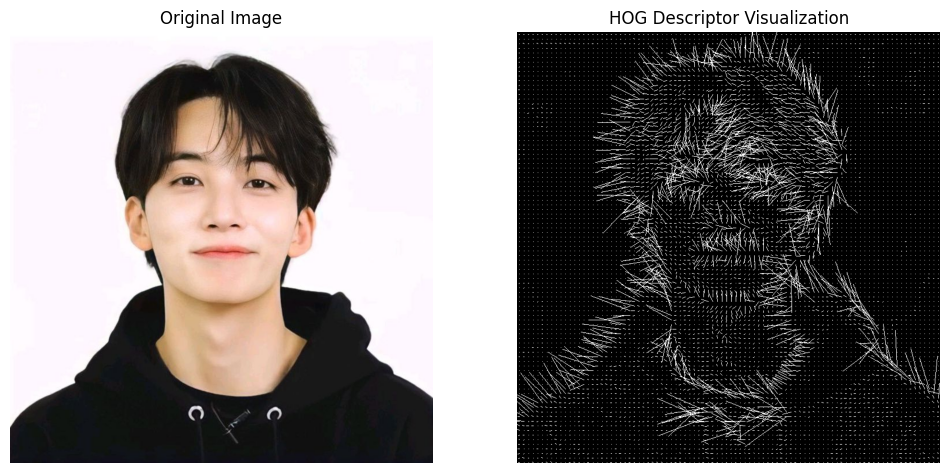

In [ ]:
# Define the path to the input image
image_path = "image.jpg"

# Read the image from the specified path
image = cv2.imread(image_path)

# Convert the image from BGR color space to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Create a Histogram of Oriented Gradients (HOG) descriptor
hog = cv2.HOGDescriptor()

# Compute HOG features from the grayscale image
hog_features = hog.compute(gray)

# Create an empty image to visualize HOG features
hog_image = np.zeros_like(gray)

# Define the size of the cells and blocks for HOG
cell_size = (8, 8)    # Size of each cell
block_size = (2, 2)   # Size of each block (in terms of cells)
block_stride = (8, 8) # Step size to move the block

# Calculate the gradient in the x and y directions using the Sobel operator
gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)

# Compute the magnitude and angle of the gradient
magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# Loop over the image in cell-sized increments
for y in range(0, gray.shape[0], cell_size[0]):
    for x in range(0, gray.shape[1], cell_size[1]):
        # Calculate the mean magnitude and angle for the current cell
        cell_magnitude = magnitude[y:y + cell_size[0], x:x + cell_size[1]].mean()
        cell_angle = angle[y:y + cell_size[0], x:x + cell_size[1]].mean()

        # Convert the angle from degrees to radians
        angle_rad = np.deg2rad(cell_angle)

        # Calculate the center of the cell
        center = (x + cell_size[0] // 2, y + cell_size[1] // 2)

        # Calculate the endpoint for the HOG visualization
        endpoint = (int(center[0] + cell_magnitude * np.cos(angle_rad)),
                    int(center[1] + cell_magnitude * np.sin(angle_rad)))

        # Draw a line from the center to the endpoint to visualize the HOG feature
        cv2.line(hog_image, center, endpoint, (255,), 1)

# Set up the figure for displaying the original image and HOG visualization
plt.figure(figsize=(12, 6))

# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Display the HOG visualization
plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap='gray')
plt.title('HOG Descriptor Visualization')
plt.axis('off')

# Show the final result
plt.show()

## FAST (Features from Accelerated Segment Test) Keypoint Detection

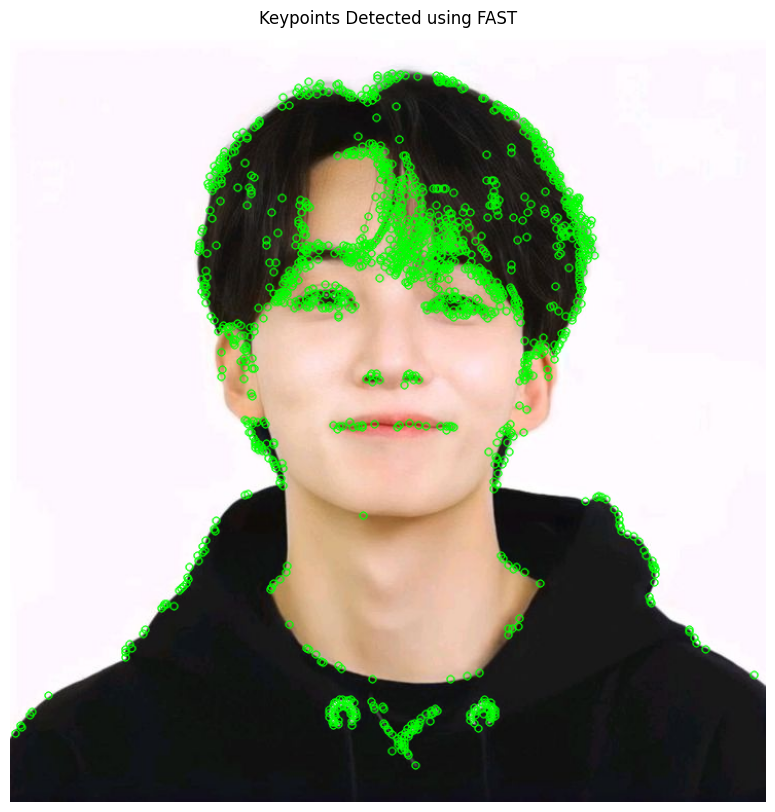

In [ ]:
# Define the path to the input image
image_path = 'image.jpg'

# Read the image from the specified path
image = cv2.imread(image_path)

# Convert the image from BGR color space to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Create a FAST (Features from Accelerated Segment Test) feature detector
fast = cv2.FastFeatureDetector_create()

# Detect keypoints in the grayscale image using the FAST detector
keypoints = fast.detect(gray_image, None)

# Draw the detected keypoints on the original image
# The keypoints are drawn in green color with rich keypoint representation
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Set up the figure for displaying the image with keypoints
plt.figure(figsize=(10, 10))

# Display the image with detected keypoints
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Turn off the axis for a cleaner presentation
plt.title('Keypoints Detected using FAST')
plt.show()

## Feature Matching using ORB and FLANN

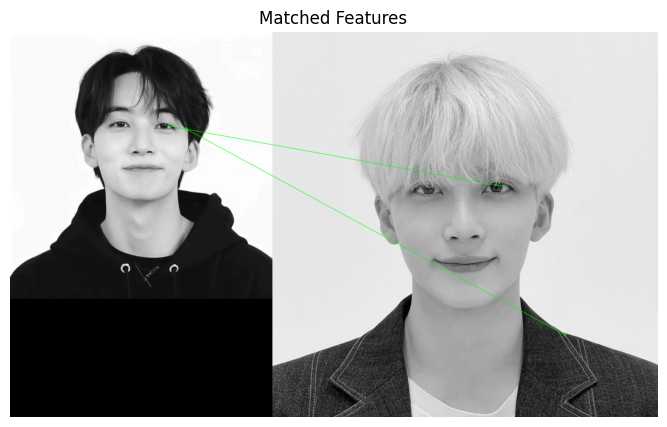

In [ ]:
# Read the first image in grayscale
img1 = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# Read the second image in grayscale
img2 = cv2.imread('photo.png', cv2.IMREAD_GRAYSCALE)

# Create an ORB (Oriented FAST and Rotated BRIEF) feature detector
orb = cv2.ORB_create()

# Detect keypoints and compute descriptors for the first image
keypoints1, descriptors1 = orb.detectAndCompute(img1, None)

# Detect keypoints and compute descriptors for the second image
keypoints2, descriptors2 = orb.detectAndCompute(img2, None)

# Set parameters for the FLANN-based matcher
index_params = dict(algorithm=6,        # Use the LSH algorithm
                    table_number=6,     # Number of hash tables
                    key_size=12,        # Number of bits per key
                    multi_probe_level=1) # Multi-probe level for better accuracy

# Set search parameters for the matcher
search_params = dict(checks=50)  # Number of times the trees in the index should be checked

# Create the FLANN-based matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Perform k-NN matching between the two sets of descriptors (k=2)
matches = flann.knnMatch(descriptors1, descriptors2, k=2)

# List to hold good matches after applying the ratio test
good_matches = []

# Apply the ratio test to filter matches
for match_pair in matches:
    if len(match_pair) == 2:  # Ensure there are two matches
        m, n = match_pair
        # Compare distances and apply the threshold
        if m.distance < 0.7 * n.distance:  # Threshold can be adjusted
            good_matches.append(m)

# Convert the grayscale images to BGR format for visualization
img1_bgr = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
img2_bgr = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

# Draw the matched keypoints between the two images
matched_img = cv2.drawMatches(img1_bgr, keypoints1, img2_bgr, keypoints2, good_matches, None,
                               matchColor=(0, 255, 0),  # Set match lines to green
                               singlePointColor=None,   # No color for single unmatched points
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Set up the figure for displaying the matched features
plt.figure(figsize=(10, 5))

# Display the image with matched features
plt.imshow(matched_img)
plt.axis('off')  # Turn off the axis for a cleaner presentation
plt.title('Matched Features')  # Set the title of the plot
plt.show()  # Show the final result


## Image Segmentation using Watershed Algorithm

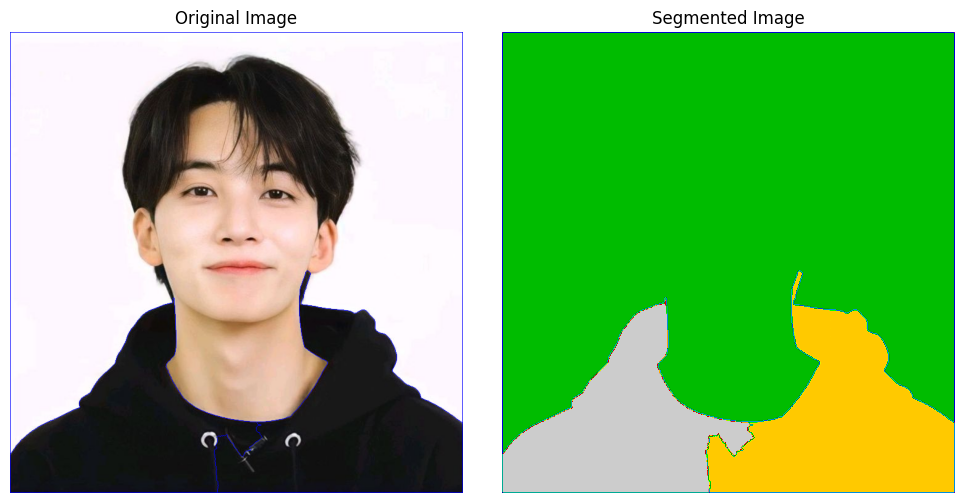

In [ ]:
# Read the input image in BGR format
image = cv2.imread('image.jpg')

# Convert the image from BGR color space to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to the grayscale image to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Perform binary thresholding on the blurred image using Otsu's method
# This inverts the binary image (foreground is white, background is black)
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Create a kernel for morphological operations
kernel = np.ones((3, 3), np.uint8)

# Apply morphological opening to remove small objects from the binary image
morph = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# Dilate the morphologically opened image to get the sure background
sure_bg = cv2.dilate(morph, kernel, iterations=3)

# Compute the distance transform of the binary image
dist_transform = cv2.distanceTransform(morph, cv2.DIST_L2, 5)

# Threshold the distance transform to obtain the sure foreground
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Identify the unknown region by subtracting sure foreground from sure background
unknown = cv2.subtract(sure_bg, np.uint8(sure_fg))

# Label the sure foreground regions
_, markers = cv2.connectedComponents(np.uint8(sure_fg))

# Increment marker labels to distinguish between different segments
markers = markers + 1
markers[unknown == 255] = 0  # Mark the unknown region with zero

# Apply the watershed algorithm for image segmentation
markers = cv2.watershed(image, markers)

# Mark the boundaries of segments with red color
image[markers == -1] = [255, 0, 0]

# Set up the figure for displaying the original and segmented images
plt.figure(figsize=(10, 5))

# Display the original image
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Turn off the axis for a cleaner presentation

# Display the segmented image using a color map
plt.subplot(1, 2, 2)
plt.title('Segmented Image')
plt.imshow(markers, cmap='nipy_spectral')  # Use a spectral color map for visualization
plt.axis('off')  # Turn off the axis for a cleaner presentation

# Adjust layout to prevent overlap of subplots
plt.tight_layout()
# Show the final result
plt.show()